# Advice checklist

## Embedding
Not implemented -> Added

## Class imbalance
Already implemented -> Added small fixes
Used a weighted random sampler after building x_train_seq

## Label smoothing
Already implemented

## Gradient clipping
Already implemented

## Auto correlation x Windowing
Not implemented -> Added

Created code section after declaration of X_train and Y_train
Given the results ChatGPT suggests:
WINDOW_SIZE     = 40 # or 32
STRIDE          = 20 # or 16
VAL_STRIDE      = 40 # or 32

RNN_TYPE        = "GRU" # Might perform slightly better than LSTM
HIDDEN_LAYERS   = 1
HIDDEN_SIZE     = 192
USE_ATTENTION   = True  # optional

BATCH_SIZE      = 64 # or 128
LEARNING_RATE   = 1e-3
DROPOUT_RATE    = 0.2
LABEL_SMOOTHING = 0.05
WEIGHT_DECAY    = 1e-4

GRAD_CLIP       = 1.0

## Time Feature Engineering
Next

LIBRARIES

In [627]:
# Set seed for reproducibility
SEED = 3740

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import acf

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
# Import PyTorch utilities for data handling
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import WeightedRandomSampler

torch.manual_seed(SEED)
from torch import nn

import optuna
from optuna.trial import TrialState


if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
#%matplotlib inline

PyTorch version: 2.9.0+cu128
Device: cuda


Hyperparameters

In [628]:
# Hyperparameters
OPTUNA_ENABLED = False
ADD_KINEMATICS = False
WEIGHTED_CLASSES = True

# Embedding
USE_CAT_EMBEDDING = True
CAT_EMBED_DIM = 4

# 1D Convolution frontend
USE_CONV = True          # set False to disable conv and use pure RNN
CONV_CHANNELS = 128       # output channels of Conv1D
CONV_KERNEL_SIZE = 5     # temporal kernel size (3 is usually enough for local patterns)

# Window size
WINDOW_SIZE = 32
# Stride for overlapping windows
STRIDE = 16

# WINDOW_SIZE = <picked_from_acf>
# STRIDE      = WINDOW_SIZE // 2   # e.g. 50% overlap for training
# VAL_STRIDE  = WINDOW_SIZE        # no overlap for validation/test

# Batch size
BATCH_SIZE = 64

# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 50
K = 5

# Architecture
HIDDEN_LAYERS = 1        # Hidden layers
HIDDEN_SIZE = 64        # Neurons per layer
RNN_TYPE = 'LSTM'
USE_ATTENTION = True
BIDIRECTIONAL = False

# Regularization
DROPOUT_RATE = 0.0     # Dropout probability
L1_LAMBDA = 1e-5       # L1 penalty
L2_LAMBDA = 1e-5       # L2 penalty
LABEL_SMOOTHING = 0.1  # Label smoothing for the classes (0 = no smoothing). Avoid going over 0.2
GRAD_CLIP_VALUE = 1.0  # Clip gradients to this norm (0 = disabled). Values 0.5 -> 5

Data Loading and Exploration

In [629]:
# Load data
X_train = pd.read_csv('Data/pirate_pain_train.csv')
y_train = pd.read_csv('Data/pirate_pain_train_labels.csv')
X_test = pd.read_csv('Data/pirate_pain_test.csv')

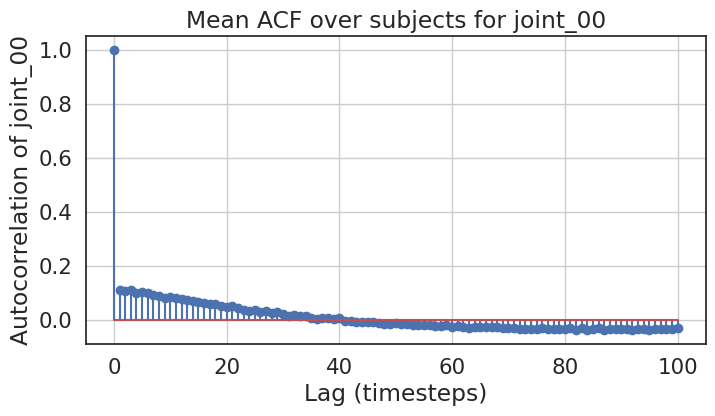

Top lags with |ACF| > 0.2:


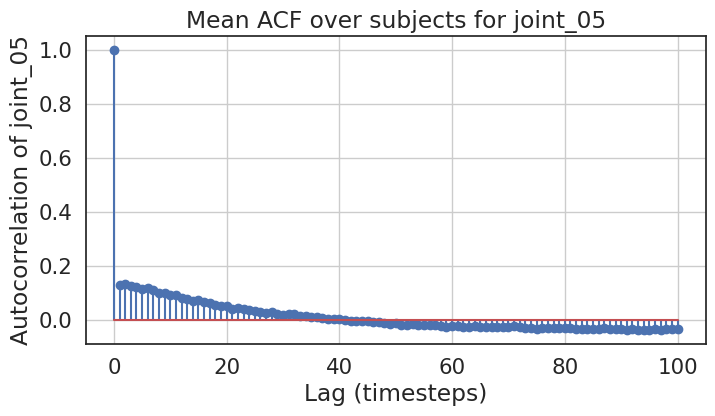

Top lags with |ACF| > 0.2:


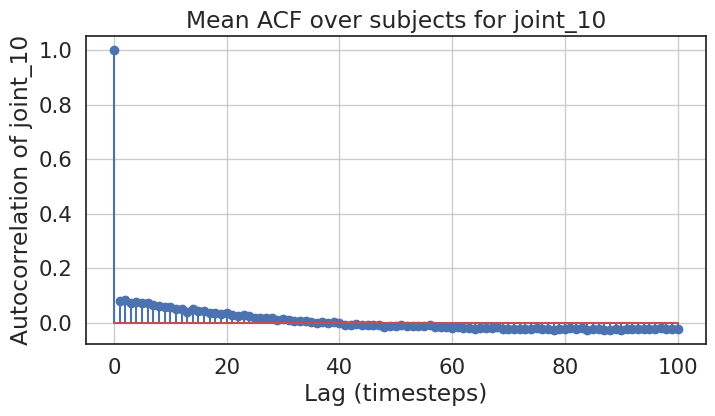

Top lags with |ACF| > 0.2:


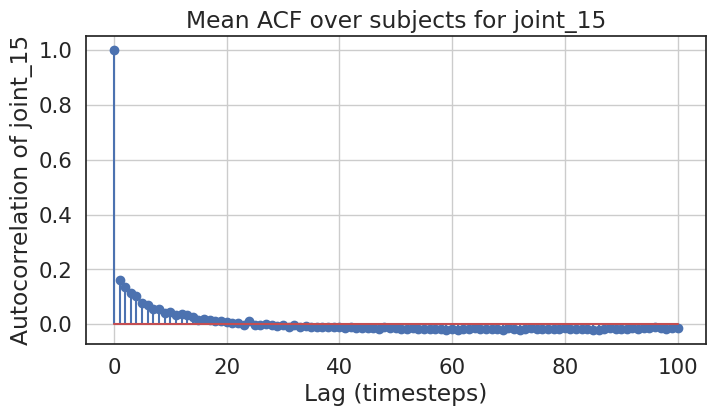

Top lags with |ACF| > 0.2:


In [630]:
def print_acf_graph(feature="joint_00", max_lag=100):
    X_sorted = X_train.sort_values(["sample_index", "time"])

    acf_list = []

    for sid, df_sub in X_sorted.groupby("sample_index"):
        x = df_sub[feature].values
        if len(x) > 2:  # need at least a few points
            # nlags=MAX_LAG, fft=True is usually faster
            acf_vals = acf(x, nlags=min(max_lag, len(x)-1), fft=True)
            # pad to the same length so we can average
            if len(acf_vals) < max_lag + 1:
                acf_vals = np.pad(acf_vals,
                                  (0, max_lag + 1 - len(acf_vals)),
                                  mode='constant',
                                  constant_values=np.nan)
            acf_list.append(acf_vals)

    acf_array = np.vstack(acf_list)      # shape: [num_subjects, MAX_LAG+1]
    mean_acf = np.nanmean(acf_array, 0)  # average across subjects

    lags = np.arange(len(mean_acf))

    plt.figure(figsize=(8, 4))
    plt.stem(lags, mean_acf)
    plt.xlabel("Lag (timesteps)")
    plt.ylabel(f"Autocorrelation of {feature}")
    plt.title(f"Mean ACF over subjects for {feature}")
    plt.grid(True)
    plt.show()

    # optionally print top lags with a strong correlation
    important = [(lag, val) for lag, val in zip(lags, mean_acf) if lag > 0 and abs(val) > 0.2]
    important = sorted(important, key=lambda x: -abs(x[1]))[:10]
    print("Top lags with |ACF| > 0.2:")
    for lag, val in important:
        print(f"lag={lag}, acf={val:.3f}")


print_acf_graph("joint_00", 100)
print_acf_graph("joint_05", 100)
print_acf_graph("joint_10", 100)
print_acf_graph("joint_15", 100)

In [631]:
# Check if there are any missing values in the datasets
print("Missing values in training data:", X_train.isnull().sum().sum())

Missing values in training data: 0


In [632]:
# Print the shape of the datasets
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (105760, 40)
Training labels shape: (661, 2)
Test data shape: (211840, 40)


In [633]:
# Print the first few rows of the training data
X_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [634]:
y_train.head()

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,low_pain
3,3,no_pain
4,4,no_pain


In [635]:
# print the number of unique classes in the labels
print("Number of unique classes in labels:", y_train['label'].nunique())

Number of unique classes in labels: 3


In [636]:
X_train.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202051,0.197608,0.295605,0.300787,...,4.974496e-03,5.472244e-03,1.235450e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746147e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,2.800090e-06,3.079465e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


In [637]:
def add_kinematic_features(df, joint_columns, sample_col='sample_index'):
    """
    Add velocity and acceleration features for joint positions using vectorized operations.

    Args:
        df: DataFrame with joint position data
        joint_columns: List of joint column names (e.g., ['joint_00', 'joint_01', ...])
        sample_col: Column name for sample/user identification

    Returns:
        DataFrame with added velocity and acceleration columns
    """
    df = df.copy()

    # Sort by sample_index to ensure continuity
    df = df.sort_values(sample_col).reset_index(drop=True)

    # Create a mask for sample boundaries (where the sample changes)
    sample_changes = df[sample_col].ne(df[sample_col].shift())

    for joint_col in joint_columns:
        velocity = df[joint_col].diff()
        # Set velocity to 0 at sample boundaries
        velocity[sample_changes] = 0

        # Compute acceleration from velocity
        acceleration = velocity.diff()
        # Set acceleration to 0 at sample boundaries
        acceleration[sample_changes] = 0

        # Store in new columns
        vel_col = joint_col.replace('joint_', 'vel_')
        acc_col = joint_col.replace('joint_', 'acc_')

        df[vel_col] = velocity
        df[acc_col] = acceleration

    return df

In [638]:
def remove_correlated_features(X_train, X_test, threshold=0.95):
    """
    Remove highly correlated features across all numeric columns.
    """
    # Get all numeric columns except identifiers
    exclude_cols = ['sample_index', 'time']
    numeric_cols = [col for col in X_train.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    # Calculate correlation matrix on all numeric features
    corr_matrix = X_train[numeric_cols].corr().abs()

    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find features with correlation greater than the threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"Removing {len(to_drop)} highly correlated feature(s) (threshold={threshold}):")
    print(to_drop)

    # Drop from both train and test
    X_train_clean = X_train.drop(columns=to_drop)
    X_test_clean = X_test.drop(columns=to_drop)

    return X_train_clean, X_test_clean, to_drop

In [639]:
# Count the number of unique users
print("Number of unique users:", X_train['sample_index'].nunique())

Number of unique users: 661


In [640]:
# Create custom maps for the categorical features
legs_custom_map = {
    'one+peg_leg': 1,
    'two': 2
}
hands_custom_map = {
    'one+hook_hand': 1,
    'two': 2
}
eyes_custom_map = {
    'one+eye_patch': 1,
    'two': 2
}
class_labels_map = {
    'no_pain' : 0,
    'low_pain' : 1,
    'high_pain' : 2
}

# Apply the custom maps to the categorical features and labels
X_train['n_legs'] = X_train['n_legs'].map(legs_custom_map)
X_train['n_hands'] = X_train['n_hands'].map(hands_custom_map)
X_train['n_eyes'] = X_train['n_eyes'].map(eyes_custom_map)
y_train['label'] = y_train['label'].map(class_labels_map)

In [641]:
# Drop the last column
X_train = X_train.drop(columns=['joint_30'])
X_test = X_test.drop(columns=['joint_30'])

# Remove correlated features
X_train, X_test, dropped_cols = remove_correlated_features(X_train, X_test, threshold=0.90)

# Update joint_columns to exclude dropped features
joint_columns = [col for col in [f'joint_{i:02d}' for i in range(30)] if col not in dropped_cols]

# Add kinematic features
if ADD_KINEMATICS:
    print("Adding velocity and acceleration features...")
    X_train = add_kinematic_features(X_train, joint_columns)
    X_test = add_kinematic_features(X_test, joint_columns)

# Verify features
print(f"New training data shape: {X_train.shape}")
print(f"New test data shape: {X_test.shape}")
print(f"Sample columns: {X_train.columns.tolist()[:]}")

Removing 3 highly correlated feature(s) (threshold=0.9):
['n_hands', 'n_eyes', 'joint_11']
New training data shape: (105760, 36)
New test data shape: (211840, 36)
Sample columns: ['sample_index', 'time', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'n_legs', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']


In [642]:
X_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,joint_00,joint_01,joint_02,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
0,0,0,2,0,2,1,2,1.094705,0.985281,1.018302,...,6.140248e-07,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815
1,0,1,2,2,2,2,2,1.135183,1.021175,0.994343,...,1.931978e-06,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716
2,0,2,2,0,2,2,2,1.080745,0.962842,1.009588,...,5.730838e-07,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105
3,0,3,2,2,2,2,2,0.938017,1.081592,0.998021,...,3.677486e-05,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648
4,0,4,2,2,2,2,2,1.090185,1.032145,1.008710,...,2.037939e-05,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328


Data Preprocessing and Splitting

In [643]:
# Check the distribution of labels
print("Label distribution:\n", y_train['label'].value_counts())

Label distribution:
 label
0    511
1     94
2     56
Name: count, dtype: int64


In [644]:
# Check the length of the time series for each user
print("Length of time series for each user:")
time_series_lengths = X_train.groupby('sample_index').size()
print(time_series_lengths)

Length of time series for each user:
sample_index
0      160
1      160
2      160
3      160
4      160
      ... 
656    160
657    160
658    160
659    160
660    160
Length: 661, dtype: int64


In [645]:
# Dynamically count remaining joints after correlation removal
num_joints = len([col for col in X_train.columns if col.startswith('joint_')])

if ADD_KINEMATICS:
    # pain(4) + cat(1) + joints(N) + vel(N) + acc(N)
    input_shape = (WINDOW_SIZE, 4 + 1 + 1 + num_joints * 3)
else:
    # pain(4) + cat(1) + joints(N)
    input_shape = (WINDOW_SIZE, 4 + 1 + 1 + num_joints)

num_classes = 3  # no_pain, low_pain, high_pain

print(f"Input shape: {input_shape} (using {num_joints} joint columns)")

Input shape: (32, 35) (using 29 joint columns)


In [646]:
# Define a function to build sequences from the dataset
def build_sequences(x_df, y_df, window=160, stride=160):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialize lists to store sequences and their corresponding labels
    dataset = []
    labels = []
    ids_list = []

    # Define feature columns
    pain_surveys = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
    cat_cols = ['n_legs']

    # Dynamically discover joint columns that exist in the data
    joint_cols = [col for col in x_df.columns if col.startswith('joint_')]

    if ADD_KINEMATICS:
        # Build velocity and acceleration columns based on available joint columns
        vel_cols = [col.replace('joint_', 'vel_') for col in joint_cols]
        acc_cols = [col.replace('joint_', 'acc_') for col in joint_cols]
        feature_cols = pain_surveys + cat_cols + ['time'] + joint_cols + vel_cols + acc_cols
    else:
        feature_cols = pain_surveys + cat_cols + ['time'] + joint_cols

    # Iterate over unique IDs in the DataFrame
    for id in x_df['sample_index'].unique():
        # Extract sensor data for the current sample ID
        temp = x_df[x_df['sample_index'] == id][feature_cols].values

        # Retrieve the label for the current sample ID
        label = y_df[y_df['sample_index'] == id]['label'].values[0]

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Set padding length to zero to avoid adding an unnecessary full window of zeros in case len(temp) % window == 0
        if padding_len == window and len(temp) % window == 0:
             padding_len = 0

        # Determine the number of features in the data
        num_features = temp.shape[1]

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, num_features), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label)
            ids_list.append(id)
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)
    ids_list = np.array(ids_list)

    return dataset, labels, ids_list

In [647]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine the optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [648]:
# Calculate class weights based on inverse frequency
class_counts = y_train['label'].value_counts().sort_index()
total_samples = len(y_train)

# Compute class weights
class_weights = total_samples / (num_classes * class_counts.values)

# Convert to tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\nClass distribution:")
print(class_counts)
print("\nClass weights:")
for i, weight in enumerate(class_weights):
    print(f"Class {i}: {weight:.4f}")


Class distribution:
label
0    511
1     94
2     56
Name: count, dtype: int64

Class weights:
Class 0: 0.4312
Class 1: 2.3440
Class 2: 3.9345


Model Building and Summary

In [667]:
def recurrent_summary(model, input_size):
        """
        Custom summary function that counts parameters for RNN/GRU/LSTM, Conv1D,
        Attention, and Linear layers.

        Args:
            model (nn.Module): The model to analyze.
            input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
        """

        output_shapes = {}
        hooks = []

        def get_hook(name):
            """Factory function to create a forward hook for a specific module."""
            def hook(module, input, output):
                # Handle tuple outputs (e.g., RNN returns (output, hidden))
                if isinstance(output, tuple):
                    output_shapes[name] = output[0].shape
                else:
                    output_shapes[name] = output.shape
            return hook

        # Determine device
        try:
            device = next(model.parameters()).device
        except StopIteration:
            device = torch.device("cpu")

        # Create dummy input
        dummy_input = torch.randn(1, *input_size).to(device)

        # Register hooks for all relevant layer types
        for name, module in model.named_children():
            if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM, nn.Conv1d, AttentionLayer, nn.Embedding)):
                handle = module.register_forward_hook(get_hook(name))
                hooks.append(handle)

        # Forward pass
        model.eval()
        with torch.no_grad():
            try:
                _ = model(dummy_input)
            except Exception as e:
                print(f"Warning: Forward pass failed: {e}")

        # Remove hooks
        for h in hooks:
            h.remove()

        # Print summary table
        print("-" * 79)
        print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
        print("=" * 79)

        total_params = 0
        total_trainable_params = 0

        for name, module in model.named_children():
            if name in output_shapes:
                # Get output shape
                shape_str = str(tuple(output_shapes[name]))

                # Calculate parameters based on layer type
                num_params = 0

                if isinstance(module, nn.Linear):
                    num_params = module.in_features * module.out_features
                    if module.bias is not None:
                        num_params += module.out_features
                    layer_type = "Linear"

                elif isinstance(module, nn.Embedding):
                    num_params = module.num_embeddings * module.embedding_dim
                    layer_type = "Embedding"

                elif isinstance(module, nn.Conv1d):
                    # Conv1d: in_channels * out_channels * kernel_size
                    num_params = (module.in_channels * module.out_channels *
                                 module.kernel_size[0])
                    if module.bias is not None:
                        num_params += module.out_channels
                    layer_type = "Conv1d"

                elif isinstance(module, AttentionLayer):
                    # AttentionLayer has one Linear layer
                    if hasattr(module, 'attention_weights'):
                        linear = module.attention_weights
                        num_params = linear.in_features * linear.out_features
                        if linear.bias is not None:
                            num_params += linear.out_features
                    layer_type = "Attention"

                elif isinstance(module, (nn.RNN, nn.GRU, nn.LSTM)):
                    # RNN parameter calculation
                    input_size = module.input_size
                    hidden_size = module.hidden_size
                    num_layers = module.num_layers
                    bidirectional = module.bidirectional

                    if isinstance(module, nn.LSTM):
                        # LSTM has 4 gates per layer
                        gate_size = 4 * hidden_size
                    else:
                        # RNN/GRU have 3 gates per layer
                        gate_size = 3 * hidden_size if isinstance(module, nn.GRU) else hidden_size

                    # First layer
                    num_params = (input_size + hidden_size) * gate_size

                    # Remaining layers
                    for _ in range(1, num_layers):
                        num_params += (hidden_size * (2 if bidirectional else 1) + hidden_size) * gate_size

                    # Double for bidirectional
                    if bidirectional:
                        num_params *= 2

                    # Add bias terms
                    num_params += gate_size * num_layers * (2 if bidirectional else 1)

                    layer_type = type(module).__name__

                else:
                    layer_type = type(module).__name__

                # Count trainable params
                trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
                total_trainable_params += trainable
                total_params += num_params

                print(f"{name + f' ({layer_type})':<25} {shape_str:<28} {num_params:>15,}")

        print("=" * 79)
        print(f"Total params: {total_params:,}")
        print(f"Trainable params: {total_trainable_params:,}")
        print(f"Non-trainable params: {total_params - total_trainable_params:,}")
        print("-" * 79)

In [650]:
class AttentionLayer(nn.Module):
    """
    Additive (Bahdanau-style) attention mechanism.
    Computes attention weights over sequence outputs and returns weighted context.
    """
    def __init__(self, hidden_size):
        super().__init__()
        # Learnable parameters for attention scoring
        self.attention_weights = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, rnn_outputs):
        """
        Args:
            rnn_outputs: (batch_size, seq_len, hidden_size)

        Returns:
            context: (batch_size, hidden_size) - weighted sum of outputs
            attention_weights: (batch_size, seq_len) - attention distribution
        """
        # Compute attention scores for each timestep
        # Shape: (batch_size, seq_len, 1)
        scores = self.attention_weights(rnn_outputs)

        # Apply softmax to get attention weights
        # Shape: (batch_size, seq_len, 1)
        attention_weights = torch.softmax(scores, dim=1)

        # Compute the weighted sum of hidden states
        # Shape: (batch_size, hidden_size)
        context = torch.sum(attention_weights * rnn_outputs, dim=1)

        # Return context and weights (for visualization)
        return context, attention_weights.squeeze(-1)

In [651]:
class LabelSmoothingCrossEntropy(nn.Module):
    """
    CrossEntropyLoss with label smoothing.

    Args:
        smoothing: Label smoothing factor (0.0 to 1.0)
        weight: Class weights for imbalanced datasets
    """
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, pred, target):
        """
        Args:
            pred: (batch_size, num_classes) - raw logits
            target: (batch_size,) - class indices
        """
        n_classes = pred.size(-1)
        log_probs = torch.nn.functional.log_softmax(pred, dim=-1)

        # Create smoothed targets
        with torch.no_grad():
            # Start with uniform distribution
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            # Set the correct class to 1 - smoothing
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

            # Apply class weights if provided
            if self.weight is not None:
                true_dist = true_dist * self.weight.unsqueeze(0)

        # Compute KL divergence loss
        loss = torch.sum(-true_dist * log_probs, dim=-1)

        return loss.mean()

In [652]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier with an optional attention mechanism.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',
            bidirectional=False,
            dropout_rate=0.2,
            use_attention=True,  # NEW PARAMETER
            use_cat_embedding=True,
            cat_embed_dim=4,
            use_conv=False,
            conv_channels=64,
            conv_kernel_size=3,
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.use_attention = use_attention  # Store flag
        self.use_cat_embedding = use_cat_embedding
        self.cat_embed_dim = cat_embed_dim
        self.use_conv = use_conv

        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        # --- Conv1D frontend over time (optional) ---
        if self.use_conv:
            # Input to Conv1D will be (batch, input_size, seq_len)
            self.conv1 = nn.Conv1d(
                in_channels=input_size,
                out_channels=conv_channels,
                kernel_size=conv_kernel_size,
                padding=conv_kernel_size // 2,  # keep seq_len the same
            )
            self.conv_act = nn.ReLU()
            conv_output_size = conv_channels
        else:
            conv_output_size = input_size

        rnn_module = rnn_map[rnn_type]
        dropout_val = dropout_rate if num_layers > 1 else 0

        self.rnn = rnn_module(
            input_size=conv_output_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate RNN output size
        rnn_output_size = hidden_size * 2 if bidirectional else hidden_size

         # Embedding for legs
        if self.use_cat_embedding:
            # values are 1 or 2 (we allow index 0 unused)
            num_categories = 3 # indices: 0, 1, 2
            self.legs_emb = nn.Embedding(num_embeddings=num_categories, embedding_dim=cat_embed_dim)
            cat_total_dim = cat_embed_dim
        else:
            cat_total_dim = 0

        # Add attention layer if enabled
        if self.use_attention:
            self.attention = AttentionLayer(rnn_output_size)
            classifier_input_size = rnn_output_size + cat_total_dim
        else:
            # Without attention, use the last hidden state
            classifier_input_size = rnn_output_size + cat_total_dim

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """
        # Keep a copy of the original input for embeddings (n_legs lives here)
        orig_x = x

        # --- Optional Conv1D frontend over time ---
        if self.use_conv:
            # (B, T, F) -> (B, F, T)
            x = x.permute(0, 2, 1)
            x = self.conv1(x)
            x = self.conv_act(x)
            # back to (B, T, C)
            x = x.permute(0, 2, 1)

        # Get RNN outputs
        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        if self.use_cat_embedding:
            # Extract only n_legs (5th feature, index 4)
            legs_raw = x[:, 0, 4]  # (batch,)
            legs_idx = legs_raw.round().long().clamp(0, 2)
            legs_emb = self.legs_emb(legs_idx)  # (batch, cat_embed_dim)

            # Use only the embedded n_legs
            cat_emb = legs_emb
        else:
            cat_emb = None

        # Attention or last hidden
        if self.use_attention:
            context, attention_weights = self.attention(rnn_out)  # (batch, rnn_output_size)
            base_repr = context
        else:
            if self.rnn_type == 'LSTM':
                hidden = hidden[0]

            if self.bidirectional:
                hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
                base_repr = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
            else:
                base_repr = hidden[-1]

        # Concatenate categorical embedding if used
        if cat_emb is not None:
            combined = torch.cat([base_repr, cat_emb], dim=-1)
        else:
            combined = base_repr

        logits = self.classifier(combined)
        return logits

Network Architecture and Training Hyperparameters

In [668]:
# Create the model with the chosen hyperparameters and display its architecture
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1],
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=BIDIRECTIONAL,
    rnn_type=RNN_TYPE,
    use_attention=USE_ATTENTION,
    use_cat_embedding=USE_CAT_EMBEDDING,
    cat_embed_dim=CAT_EMBED_DIM,
    use_conv=USE_CONV,
    conv_channels=CONV_CHANNELS,
    conv_kernel_size=CONV_KERNEL_SIZE
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
conv1 (Conv1d)            (1, 128, 32)                          22,528
rnn (LSTM)                (1, 32, 64)                           49,408
legs_emb (Embedding)      (1, 4)                                    12
attention (Attention)     (1, 64)                                   64
classifier (Linear)       (1, 3)                                   207
Total params: 72,219
Trainable params: 72,475
Non-trainable params: -256
-------------------------------------------------------------------------------


Model Training

In [654]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [655]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.
    (L2 logic is handled by AdamW's weight_decay)
    """
    model.train()  # Set the model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Loader may yield (inputs, targets) or (inputs, targets, ids)
    # We only need the first two for training.
    for batch_idx, (inputs, targets, *_) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from the previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 regularization (L2 is handled by AdamW)
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

        # Gradient clipping (unscale first for accurate clipping)
        if GRAD_CLIP_VALUE > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_VALUE)

        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [656]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.
    Aggregates logits per user before calculating F1 score.
    """
    model.eval()  # Set the model to evaluation mode

    running_loss = 0.0
    all_logits = []
    all_targets = []
    all_user_ids = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets, user_ids in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)

            # Store results for aggregation
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu().numpy())
            all_user_ids.append(user_ids.cpu().numpy())

    # Concatenate all batch results
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = np.concatenate(all_targets)
    all_user_ids = np.concatenate(all_user_ids)

    # Create a DataFrame to manage window-level results
    results_df = pd.DataFrame({
        'sample_index': all_user_ids,
        'target': all_targets,
        'logit_0': all_logits[:, 0].numpy(),
        'logit_1': all_logits[:, 1].numpy(),
        'logit_2': all_logits[:, 2].numpy()
    })

    # Average logits across all windows for each sample_index
    user_agg = results_df.groupby('sample_index').agg({
        'logit_0': 'mean',
        'logit_1': 'mean',
        'logit_2': 'mean',
        'target': lambda x: x.iloc[0]  # All targets for a given user are the same
    })

    # Get final predictions by taking argmax of the averaged logits
    user_logits = user_agg[['logit_0', 'logit_1', 'logit_2']].values
    user_preds = np.argmax(user_logits, axis=1)
    user_targets = user_agg['target'].values

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(user_targets, user_preds, average='weighted')

    return epoch_loss, epoch_f1

In [657]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.
    (Removed l2_lambda from params as it's passed to AdamW)
    """

    # Define the directory for saving models if it doesn't exist yet'
    MODEL_DIR = "models"

    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR, exist_ok=True)
        print(f"Created directory: {MODEL_DIR}")

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0 and val_loader:  # Only enable if we have patience AND a val_loader
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"\nTraining {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # --- Training ---
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda
        )
        training_history['train_loss'].append(train_loss)
        training_history['train_f1'].append(train_f1)

        # --- Validation & Early Stopping (Only if val_loader is provided) ---
        if val_loader:
            val_loss, val_f1 = validate_one_epoch(
                model, val_loader, criterion, device
            )
            training_history['val_loss'].append(val_loss)
            training_history['val_f1'].append(val_f1)

            # Print progress every N epochs or on the first epoch
            if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                      f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

            # Early stopping logic
            if patience > 0:
                current_metric = training_history[evaluation_metric][-1]
                is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

                if is_improvement:
                    best_metric = current_metric
                    best_epoch = epoch
                    torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early stopping triggered after {epoch} epochs.")
                        break

        # --- No Validation (Full Dataset Training) ---
        else:
            training_history['val_loss'].append(None)
            training_history['val_f1'].append(None)
            # Just print training progress
            if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f}")

    # --- Post-Training ---

    # Restore the best model weights if early stopping was used
    if restore_best_weights and patience > 0 and val_loader:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save the final model if no early stopping (or no validation loader)
    if patience == 0 or not val_loader:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [658]:
# Optuna objective function
def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
    hidden_size = trial.suggest_categorical('hidden_size', [32, 128])
    hidden_layers = trial.suggest_int('hidden_layers', 1, 3)
    dropout_rate = trial.suggest_float('dropout_rate', 0, 0.4)
    l1_lambda = trial.suggest_float('l1_lambda', 1e-6, 1e-3, log=True)
    l2_lambda = trial.suggest_float('l2_lambda', 1e-6, 1e-3, log=True)

    all_fold_f1 = []
    df_train_data = X_train.copy()
    # Dynamically discover joint columns (after correlation removal)
    joint_cols_present = [col for col in df_train_data.columns if col.startswith('joint_')]
    scale_columns = joint_cols_present.copy()

    if ADD_KINEMATICS:
        vel_cols = [c.replace('joint_', 'vel_') for c in joint_cols_present]
        acc_cols = [c.replace('joint_', 'acc_') for c in joint_cols_present]
        scale_columns = scale_columns + vel_cols + acc_cols

    # K-Fold Cross-Validation
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

    # Get unique users and their labels (one label per user)
    unique_users = X_train['sample_index'].unique()
    user_labels = []
    for user in unique_users:
        label = y_train[y_train['sample_index'] == user]['label'].iloc[0]
        user_labels.append(label)

    user_labels = np.array(user_labels)

    # Perform K-Fold Cross-Validation
    for fold, (train_idx, val_idx) in enumerate(skf.split(unique_users, user_labels), 1):
        # Split users
        train_users = unique_users[train_idx]
        val_users = unique_users[val_idx]

        # Split data
        df_train_data = X_train[X_train['sample_index'].isin(train_users)].copy()
        df_train_labels = y_train[y_train['sample_index'].isin(train_users)].copy()
        df_val_data = X_train[X_train['sample_index'].isin(val_users)].copy()
        df_val_labels = y_train[y_train['sample_index'].isin(val_users)].copy()

        # Normalize
        scaler = StandardScaler()
        scaler.fit(df_train_data[scale_columns])
        df_train_data[scale_columns] = scaler.transform(df_train_data[scale_columns])
        df_val_data[scale_columns] = scaler.transform(df_val_data[scale_columns])

        # Build sequences
        X_train_seq, y_train_seq, ids_train_seq = build_sequences(df_train_data, df_train_labels, WINDOW_SIZE, STRIDE)
        X_val_seq, y_val_seq, ids_val_seq = build_sequences(df_val_data, df_val_labels, WINDOW_SIZE, STRIDE)

        # Create loaders
        train_ds = TensorDataset(
            torch.from_numpy(X_train_seq).float(),
            torch.from_numpy(y_train_seq).long(),
            torch.from_numpy(ids_train_seq).long()
        )
        val_ds = TensorDataset(
            torch.from_numpy(X_val_seq).float(),
            torch.from_numpy(y_val_seq).long(),
            torch.from_numpy(ids_val_seq).long()
        )

        # Compute sample-level weights
        class_sample_counts = np.bincount(y_train_seq)
        class_weights = 1.0 / class_sample_counts
        sample_weights = class_weights[y_train_seq]

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            sampler=sampler,           # instead of shuffle=True
            pin_memory=True,
            drop_last=True
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            pin_memory=True,
            drop_last=False
        )

        # train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, drop_last=True)
        # val_loader = make_loader(val_ds, BATCH_SIZE, shuffle=False, drop_last=False)

        # Calculate fold-specific class weights if enabled
        if WEIGHTED_CLASSES:
            fold_class_counts = pd.Series(y_train_seq).value_counts().sort_index()
            fold_class_weights = len(y_train_seq) / (num_classes * fold_class_counts.values)
            class_weights_fold = torch.FloatTensor(fold_class_weights).to(device)
            criterion_fold = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, weight=class_weights_fold)
        else:
            criterion_fold = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

        # Create model
        model = RecurrentClassifier(
            input_size=input_shape[-1],
            hidden_size=hidden_size,
            num_layers=hidden_layers,
            num_classes=num_classes,
            dropout_rate=dropout_rate,
            bidirectional=BIDIRECTIONAL,
            rnn_type=RNN_TYPE,
            use_attention=USE_ATTENTION,
            use_cat_embedding=USE_CAT_EMBEDDING,
            cat_embed_dim=CAT_EMBED_DIM,
            use_conv=USE_CONV,
            conv_channels=CONV_CHANNELS,
            conv_kernel_size=CONV_KERNEL_SIZE
        ).to(device)

        optimizer_fold = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=l2_lambda)
        scaler_fold = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

        # Train (reduced epochs for tuning)
        model, fold_history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=300,
            criterion=criterion_fold,
            optimizer=optimizer_fold,
            scaler=scaler_fold,
            device=device,
            l1_lambda=l1_lambda,
            patience=30,
            verbose=0,
            experiment_name=f"optuna_trial{trial.number}_fold{fold}"
        )

        # Get best F1
        best_val_f1 = np.max(fold_history['val_f1'])
        all_fold_f1.append(best_val_f1)

        # Pruning
        trial.report(np.mean(all_fold_f1), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(all_fold_f1)

In [659]:
if OPTUNA_ENABLED:
    # Run hyperparameter optimization
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(
        direction="maximize",
        study_name=f"{RNN_TYPE}_Pain_Classification",
        pruner=optuna.pruners.PercentilePruner(percentile=60, n_warmup_steps=1, n_startup_trials=5)
    )

    study.optimize(objective, n_trials=100, show_progress_bar=True)

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)
    print(f"Best Mean F1: {study.best_value:.4f}")
    print("\nBest Hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    print("="*60)

In [660]:
if OPTUNA_ENABLED:
    # Apply optimized hyperparameters
    LEARNING_RATE = study.best_params['lr']
    HIDDEN_SIZE = study.best_params['hidden_size']
    HIDDEN_LAYERS = study.best_params['hidden_layers']
    DROPOUT_RATE = study.best_params['dropout_rate']
    L1_LAMBDA = study.best_params['l1_lambda']
    L2_LAMBDA = study.best_params['l2_lambda']

    print("\nUpdated hyperparameters for final training:")
    print(f"Learning Rate: {LEARNING_RATE:.6f}")
    print(f"Hidden Size: {HIDDEN_SIZE}")
    print(f"Hidden Layers: {HIDDEN_LAYERS}")
    print(f"Dropout Rate: {DROPOUT_RATE:.4f}")
    print(f"L1 Lambda: {L1_LAMBDA:.6f}")
    print(f"L2 Lambda: {L2_LAMBDA:.6f}")

In [661]:
# Prepare for k-fold cross-validation
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

# Get unique users and their labels (one label per user)
unique_users = X_train['sample_index'].unique()
user_labels = []
for user in unique_users:
    label = y_train[y_train['sample_index'] == user]['label'].iloc[0]
    user_labels.append(label)

user_labels = np.array(user_labels)

# Store results for each fold
fold_results = []

df_train_data = X_train.copy()
# Dynamically discover joint columns (after correlation removal)
joint_cols_present = [col for col in df_train_data.columns if col.startswith('joint_')]
scale_columns = joint_cols_present.copy()

if ADD_KINEMATICS:
    vel_cols = [c.replace('joint_', 'vel_') for c in joint_cols_present]
    acc_cols = [c.replace('joint_', 'acc_') for c in joint_cols_present]
    scale_columns = scale_columns + vel_cols + acc_cols

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_users, user_labels), 1):
    print(f"\n{'='*50}")
    print(f"Final Training Fold {fold}/{K} with optimized hyperparameters:")
    print(f"{'='*50}")

    # Split users
    train_users = unique_users[train_idx]
    val_users = unique_users[val_idx]

    # Split data
    df_train_data = X_train[X_train['sample_index'].isin(train_users)].copy()
    df_train_labels = y_train[y_train['sample_index'].isin(train_users)].copy()
    df_val_data = X_train[X_train['sample_index'].isin(val_users)].copy()
    df_val_labels = y_train[y_train['sample_index'].isin(val_users)].copy()

    # Check label distribution
    print(f"Training set label distribution:\n{df_train_labels['label'].value_counts().sort_index()}")
    print(f"Validation set label distribution:\n{df_val_labels['label'].value_counts().sort_index()}")

    # Normalize data
    scaler = StandardScaler()
    scaler.fit(df_train_data[scale_columns])

    # Transform both train and val data
    df_train_data[scale_columns] = scaler.transform(df_train_data[scale_columns])
    df_val_data[scale_columns] = scaler.transform(df_val_data[scale_columns])

    # Build sequences
    X_train_seq, y_train_seq, ids_train_seq = build_sequences(df_train_data, df_train_labels, WINDOW_SIZE, STRIDE)
    X_val_seq, y_val_seq, ids_val_seq = build_sequences(df_val_data, df_val_labels, WINDOW_SIZE, STRIDE)

    # Create datasets
    train_ds = TensorDataset(
        torch.from_numpy(X_train_seq).float(),
        torch.from_numpy(y_train_seq).long(),
        torch.from_numpy(ids_train_seq).long()
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val_seq).float(),
        torch.from_numpy(y_val_seq).long(),
        torch.from_numpy(ids_val_seq).long()
    )

    # Calculate fold-specific class weights based on the *windowed* training data
    if WEIGHTED_CLASSES:
        fold_class_counts = pd.Series(y_train_seq).value_counts().sort_index()
        fold_total_samples = len(y_train_seq)
        fold_class_weights = fold_total_samples / (num_classes * fold_class_counts.values)

        print("\nFold Class Weights:")
        for i, weight in enumerate(fold_class_weights):
            print(f"Class {i}: {weight:.4f}")

        # Compute sample-level weights for WeightedRandomSampler
        sample_weights = fold_class_weights[y_train_seq]

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        criterion_fold = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    else:
        sampler = None
        criterion_fold = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    # Create DataLoader with a conditional sampler
    if sampler is not None:
        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            sampler=sampler,  # Use weighted sampler
            pin_memory=True,
            drop_last=False
        )
    else:
        train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # Create tensors and loaders (now includes user IDs)
    X_train_tensor = torch.from_numpy(X_train_seq).to(torch.float32)
    X_val_tensor = torch.from_numpy(X_val_seq).to(torch.float32)
    y_train_tensor = torch.from_numpy(y_train_seq).to(torch.long)
    y_val_tensor = torch.from_numpy(y_val_seq).to(torch.long)
    ids_train_tensor = torch.from_numpy(ids_train_seq).to(torch.long)
    ids_val_tensor = torch.from_numpy(ids_val_seq).to(torch.long)

    # Dataset now contains 3 tensors
    train_ds = TensorDataset(X_train_tensor, y_train_tensor, ids_train_tensor)
    val_ds = TensorDataset(X_val_tensor, y_val_tensor, ids_val_tensor)

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # Create a fresh model for this fold
    model = RecurrentClassifier(
        input_size=input_shape[-1],
        hidden_size=HIDDEN_SIZE,
        num_layers=HIDDEN_LAYERS,
        num_classes=num_classes,
        dropout_rate=DROPOUT_RATE,
        bidirectional=BIDIRECTIONAL,
        rnn_type=RNN_TYPE,
        use_attention=USE_ATTENTION,
        use_cat_embedding=USE_CAT_EMBEDDING,
        cat_embed_dim=CAT_EMBED_DIM,
        use_conv=USE_CONV,
        conv_channels=CONV_CHANNELS,
        conv_kernel_size=CONV_KERNEL_SIZE
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    # Train the model
    model, history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        criterion=criterion_fold,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        l1_lambda=L1_LAMBDA,
        verbose=10,
        experiment_name=f"{RNN_TYPE}_fold{fold}",
        patience=PATIENCE
    )

    # Store results
    fold_results.append({
    'fold': fold,
    'val_f1': history['val_f1'][-1], # Per-user F1
    'val_loss': history['val_loss'][-1],
    'model': model,
    'history': history,
    'val_loader': val_loader
    })

    print(f"Fold {fold} - Val F1 (per-user): {history['val_f1'][-1]:.4f}")

# Calculate average performance across folds
avg_f1 = np.mean([r['val_f1'] for r in fold_results])
std_f1 = np.std([r['val_f1'] for r in fold_results])
print(f"\n{'='*50}")
print(f"Cross-Validation Results (Per-User F1):")
print(f"Average F1: {avg_f1:.4f} ± {std_f1:.4f}")
print(f"{'='*50}")


Final Training Fold 1/5 with optimized hyperparameters:
Training set label distribution:
label
0    408
1     76
2     44
Name: count, dtype: int64
Validation set label distribution:
label
0    103
1     18
2     12
Name: count, dtype: int64

Fold Class Weights:
Class 0: 0.4314
Class 1: 2.3158
Class 2: 4.0000

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.7677, F1 Score=0.7038 | Val: Loss=0.6957, F1 Score=0.7461
Epoch  10/500 | Train: Loss=0.4671, F1 Score=0.9244 | Val: Loss=0.5482, F1 Score=0.8827
Epoch  20/500 | Train: Loss=0.4069, F1 Score=0.9557 | Val: Loss=0.5614, F1 Score=0.8863
Epoch  30/500 | Train: Loss=0.3680, F1 Score=0.9738 | Val: Loss=0.4850, F1 Score=0.9297
Epoch  40/500 | Train: Loss=0.3568, F1 Score=0.9800 | Val: Loss=0.5326, F1 Score=0.9106
Epoch  50/500 | Train: Loss=0.3524, F1 Score=0.9815 | Val: Loss=0.4866, F1 Score=0.9297
Epoch  60/500 | Train: Loss=0.3386, F1 Score=0.9860 | Val: Loss=0.5353, F1 Score=0.9192
Epoch  70/500 | Train: Loss=0.3280, F1 Score=0.9

In [662]:
# Display results for each fold
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

for result in fold_results:
    print(f"Fold {result['fold']}: Mean Val F1 = {result['val_f1']:.4f}, Mean Val Loss = {result['val_loss']:.4f}")

# Calculate statistics
avg_f1 = np.mean([r['val_f1'] for r in fold_results])
std_f1 = np.std([r['val_f1'] for r in fold_results])
avg_loss = np.mean([r['val_loss'] for r in fold_results])
std_loss = np.std([r['val_loss'] for r in fold_results])

print(f"\nVal F1: {avg_f1:.4f} ± {std_f1:.4f}")
print(f"Val Loss: {avg_loss:.4f} ± {std_loss:.4f}")
print("="*60)


CROSS-VALIDATION RESULTS
Fold 1: Mean Val F1 = 0.9227, Mean Val Loss = 0.5211
Fold 2: Mean Val F1 = 0.9187, Mean Val Loss = 0.5097
Fold 3: Mean Val F1 = 0.9310, Mean Val Loss = 0.5281
Fold 4: Mean Val F1 = 0.9354, Mean Val Loss = 0.4608
Fold 5: Mean Val F1 = 0.8936, Mean Val Loss = 0.4967

Val F1: 0.9203 ± 0.0146
Val Loss: 0.5033 ± 0.0238


In [663]:
# Print the best fold val f1 score for each fold
print("\nBest validation F1 score per fold:")
for i, result in enumerate(fold_results, 1):
    best_f1 = np.max(result['history']['val_f1'])
    print(f"Fold {i}: Best val F1 = {best_f1:.4f}")

# Print the mean of all the best fold val f1 scores
best_f1_scores = [np.max(result['history']['val_f1']) for result in fold_results]
mean_best_f1 = np.mean(best_f1_scores)
print(f"\nMean of best validation F1 scores across folds: {mean_best_f1:.4f}")


Best validation F1 score per fold:
Fold 1: Best val F1 = 0.9527
Fold 2: Best val F1 = 0.9441
Fold 3: Best val F1 = 0.9614
Fold 4: Best val F1 = 0.9535
Fold 5: Best val F1 = 0.9527

Mean of best validation F1 scores across folds: 0.9529


In [664]:
# Apply categorical mappings to test data
if 'n_legs' in X_test.columns:
    X_test['n_legs'] = X_test['n_legs'].map(legs_custom_map)

if 'n_hands' in X_test.columns:
    X_test['n_hands'] = X_test['n_hands'].map(hands_custom_map)

if 'n_eyes' in X_test.columns:
    X_test['n_eyes'] = X_test['n_eyes'].map(eyes_custom_map)

survey_columns = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
candidate_categorical_columns = ['n_legs', 'n_hands', 'n_eyes']
categorical_columns = [c for c in candidate_categorical_columns if c in X_test.columns]

df_train_data = X_train.copy()
# Dynamically discover joint columns (after correlation removal)
joint_cols_present = [col for col in df_train_data.columns if col.startswith('joint_')]
scale_columns = joint_cols_present.copy()

if ADD_KINEMATICS:
    vel_cols = [c.replace('joint_', 'vel_') for c in joint_cols_present]
    acc_cols = [c.replace('joint_', 'acc_') for c in joint_cols_present]
    scale_columns = scale_columns + vel_cols + acc_cols

# Normalize only the joint features
full_scaler = StandardScaler()
full_scaler.fit(X_train[scale_columns])
X_test_normalized = X_test.copy()
X_test_normalized[scale_columns] = full_scaler.transform(X_test[scale_columns])

# Include ALL feature types (surveys + categorical + joints/kinematics)
feature_columns = survey_columns + categorical_columns + ['time'] + scale_columns

# Build windows per sample_index
per_sample_windows = []
per_sample_map = []
unique_samples = X_test_normalized['sample_index'].unique()

for sid in unique_samples:
    grp = X_test_normalized[X_test_normalized['sample_index'] == sid].reset_index(drop=True)
    grp_features = grp[feature_columns].apply(pd.to_numeric, errors='coerce').fillna(0.0).values.astype(np.float32)
    n = len(grp_features)

    if n >= WINDOW_SIZE:
        for start in range(0, n - WINDOW_SIZE + 1, STRIDE):
            window = grp_features[start:start + WINDOW_SIZE]
            per_sample_windows.append(window)
            per_sample_map.append(sid)
    else:
        pad_count = max(0, WINDOW_SIZE - n)
        pad_rows = np.repeat(grp_features[-1:, :], pad_count, axis=0)
        window = np.vstack([grp_features, pad_rows])
        per_sample_windows.append(window)
        per_sample_map.append(sid)

X_test_seq = np.stack(per_sample_windows).astype(np.float32)
print(f"Built {len(X_test_seq)} windows for {len(unique_samples)} unique samples.")
print(f"Test sequence shape: {X_test_seq.shape} (expected last dim: {input_shape[-1]})")

X_test_tensor = torch.from_numpy(X_test_seq).to(torch.float32)
test_ds = TensorDataset(X_test_tensor, torch.zeros(len(X_test_tensor)))
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# ============================================================================
# SOFT VOTING: Average logits across models AND windows per sample
# ============================================================================
print("\nGenerating soft voting predictions (averaging logits)...")

# Sort folds by validation F1 and select top N
top_folds = sorted(fold_results, key=lambda x: x['val_f1'], reverse=True)[:K]

# Collect logits from each model
all_logits = []

for fold in top_folds:
    model = fold['model']
    model.eval()
    fold_logits = []

    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            logits = model(inputs)  # Shape: (batch_size, num_classes)
            fold_logits.append(logits.cpu())

    # Concatenate all batches: shape (num_windows, num_classes)
    fold_logits = torch.cat(fold_logits, dim=0)
    all_logits.append(fold_logits)

# Average logits across all models: shape (num_windows, num_classes)
avg_model_logits = torch.stack(all_logits).mean(dim=0)

# Create DataFrame mapping windows to samples
temp_results = pd.DataFrame({
    'sample_index': per_sample_map,
    'logit_0': avg_model_logits[:, 0].numpy(),
    'logit_1': avg_model_logits[:, 1].numpy(),
    'logit_2': avg_model_logits[:, 2].numpy()
})

# Average logits across windows for each sample
sample_avg_logits = temp_results.groupby('sample_index')[['logit_0', 'logit_1', 'logit_2']].mean()

# Get final predictions by taking argmax of averaged logits
final_predictions = sample_avg_logits.values.argmax(axis=1)

# Create submission DataFrame
final_submission = pd.DataFrame({
    'sample_index': sample_avg_logits.index,
    'prediction': final_predictions
})

# Map to labels
reverse_class_map = {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
final_submission['label'] = final_submission['prediction'].map(reverse_class_map)

ensemble_submission = final_submission[['sample_index', 'label']].copy()

# Format sample_index as zero-padded 3-digit strings
try:
    ensemble_submission['sample_index'] = ensemble_submission['sample_index'].astype(int).apply(lambda x: f"{x:03d}")
except Exception:
    ensemble_submission['sample_index'] = ensemble_submission['sample_index'].astype(str)

# Save submission
ensemble_submission.to_csv('soft_voting_submission.csv', index=False)
print(f"\nSoft voting submission created with {len(ensemble_submission)} predictions.")
print("First few predictions:")
print(ensemble_submission.head(10))

Built 11916 windows for 1324 unique samples.
Test sequence shape: (11916, 32, 35) (expected last dim: 35)

Generating soft voting predictions (averaging logits)...

Soft voting submission created with 1324 predictions.
First few predictions:
  sample_index    label
0          000  no_pain
1          001  no_pain
2          002  no_pain
3          003  no_pain
4          004  no_pain
5          005  no_pain
6          006  no_pain
7          007  no_pain
8          008  no_pain
9          009  no_pain


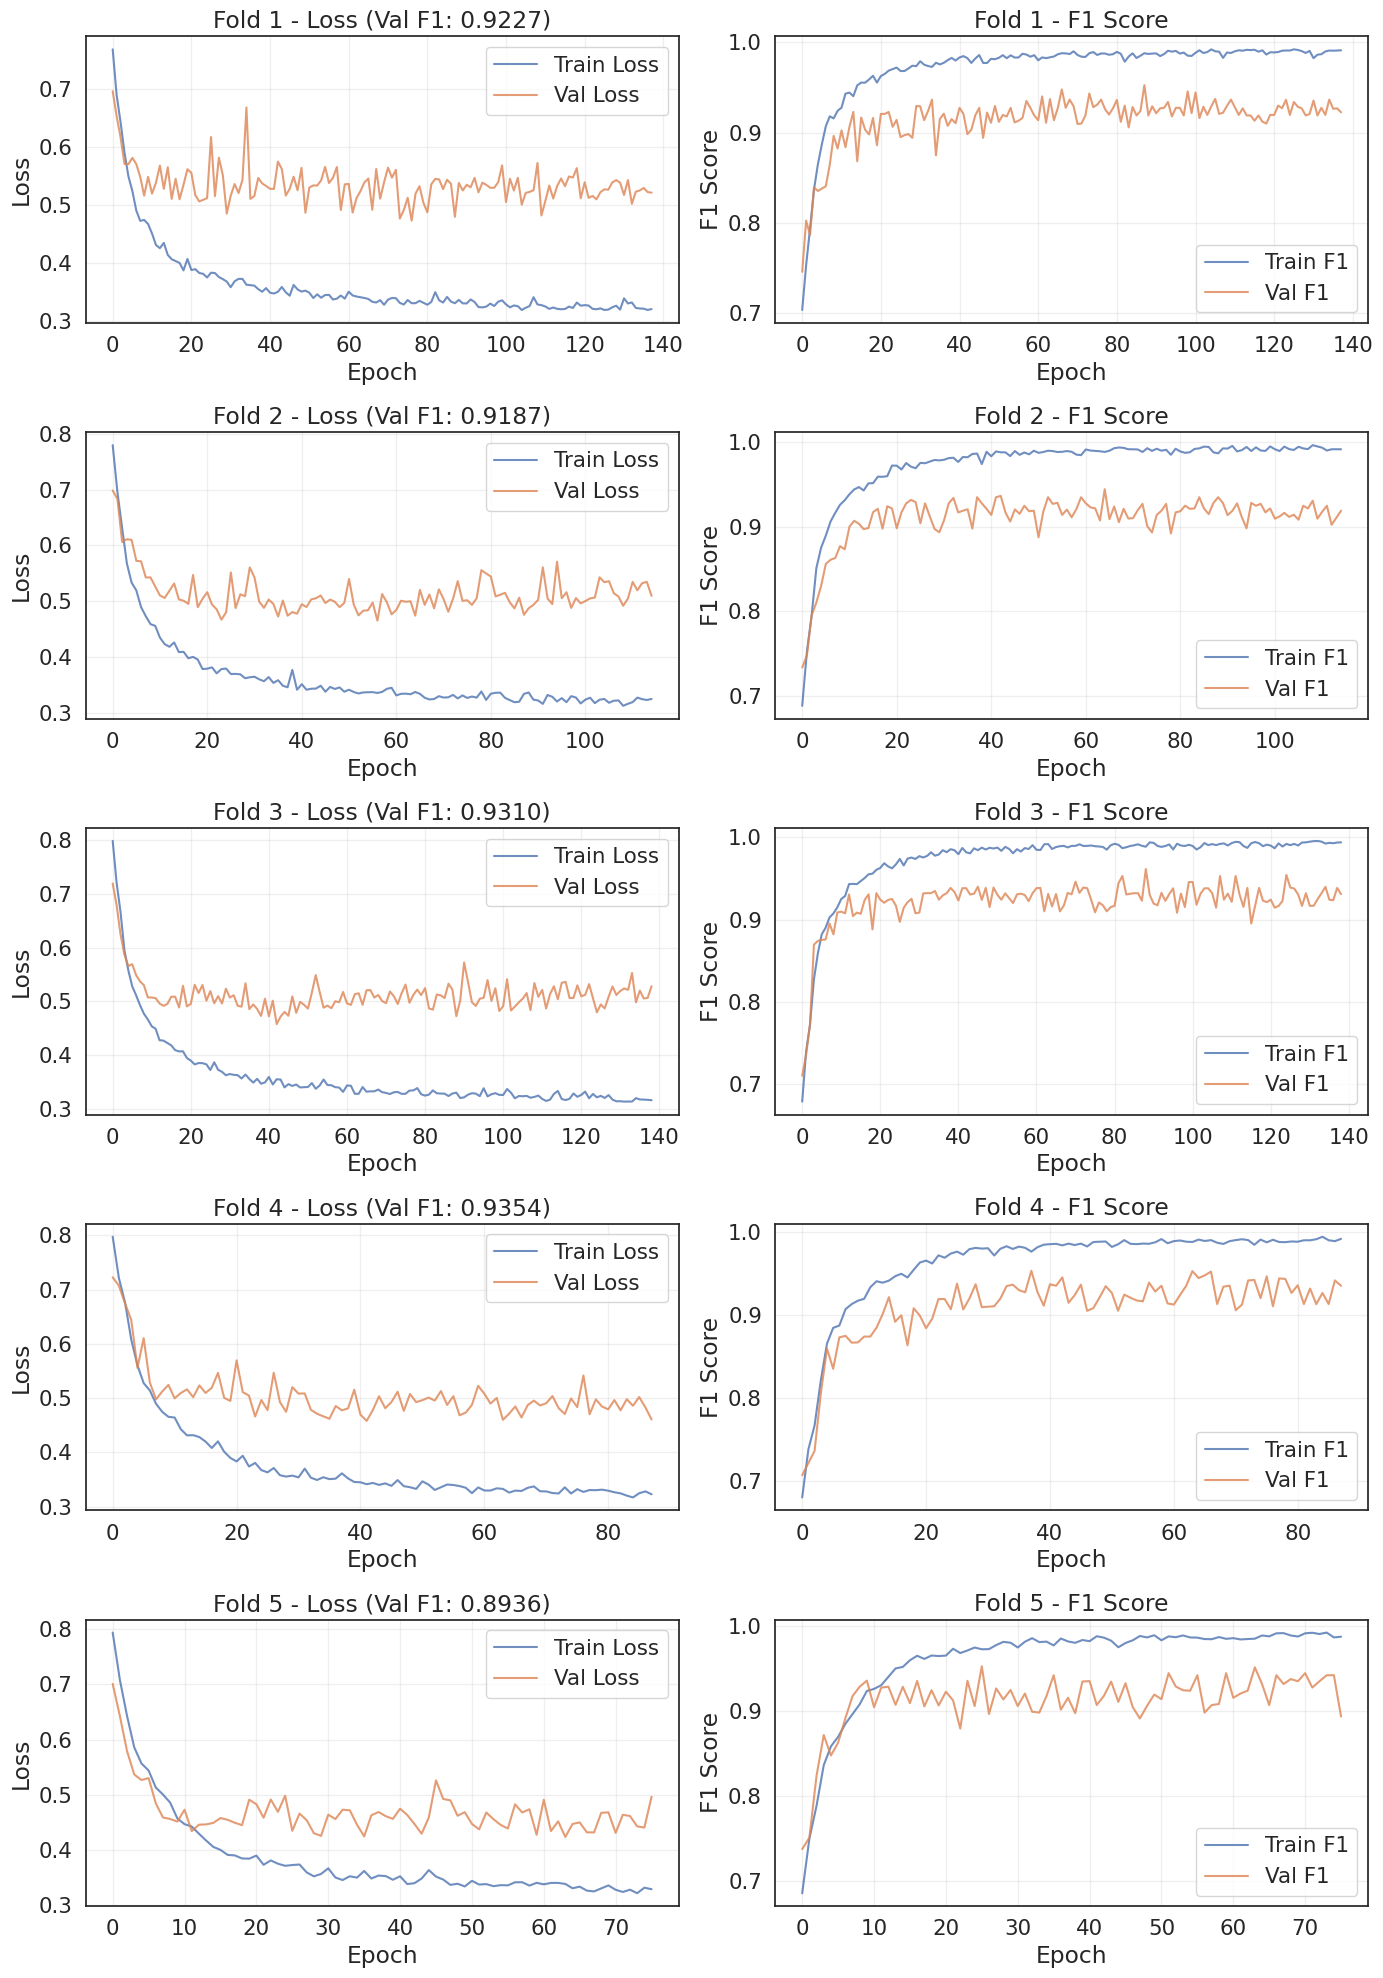

In [665]:
# Plot loss curves for all folds
fig, axes = plt.subplots(K, 2, figsize=(14, 4*K))

for i, fold in enumerate(fold_results):
    history = fold['history']

    # Loss plot
    axes[i, 0].plot(history['train_loss'], label='Train Loss', alpha=0.8)
    axes[i, 0].plot(history['val_loss'], label='Val Loss', alpha=0.8)
    axes[i, 0].set_title(f'Fold {fold["fold"]} - Loss (Val F1: {fold["val_f1"]:.4f})')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # F1 plot
    axes[i, 1].plot(history['train_f1'], label='Train F1', alpha=0.8)
    axes[i, 1].plot(history['val_f1'], label='Val F1', alpha=0.8)
    axes[i, 1].set_title(f'Fold {fold["fold"]} - F1 Score')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('F1 Score')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Generating combined confusion matrix from all folds...
Fold 1: F1=0.9527, Samples=133
Fold 2: F1=0.9441, Samples=132
Fold 3: F1=0.9614, Samples=132
Fold 4: F1=0.9535, Samples=132
Fold 5: F1=0.9527, Samples=132

Combined Validation Results:
Total samples: 661
Combined F1 Score: 0.9529


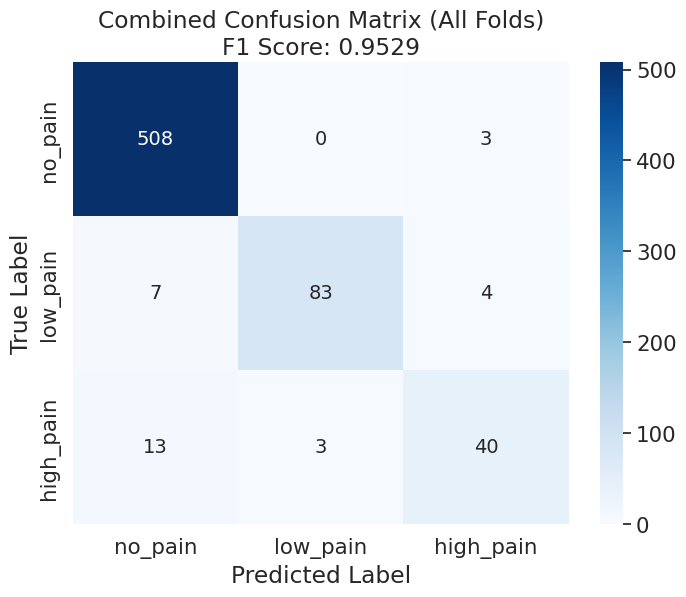


Combined Classification Metrics:
Accuracy: 0.9546
Precision (weighted): 0.9531
Recall (weighted): 0.9546


In [666]:
# Collect predictions from all folds' validation sets
all_y_true = []
all_y_pred = []

print("\nGenerating combined confusion matrix from all folds...")

for fold in fold_results:
    model = fold['model']
    val_loader = fold['val_loader']

    model.eval()
    fold_logits = []
    fold_targets = []
    fold_user_ids = []

    with torch.no_grad():
        for inputs, targets, user_ids in val_loader:
            inputs = inputs.to(device)
            logits = model(inputs)

            fold_logits.append(logits.cpu())
            fold_targets.append(targets.cpu().numpy())
            fold_user_ids.append(user_ids.cpu().numpy())

    # Concatenate batch results
    fold_logits = torch.cat(fold_logits, dim=0)
    fold_targets = np.concatenate(fold_targets)
    fold_user_ids = np.concatenate(fold_user_ids)

    # Aggregate by user (soft voting)
    results_df = pd.DataFrame({
        'sample_index': fold_user_ids,
        'target': fold_targets,
        'logit_0': fold_logits[:, 0].numpy(),
        'logit_1': fold_logits[:, 1].numpy(),
        'logit_2': fold_logits[:, 2].numpy()
    })

    user_agg = results_df.groupby('sample_index').agg({
        'logit_0': 'mean',
        'logit_1': 'mean',
        'logit_2': 'mean',
        'target': lambda x: x.iloc[0]
    })

    user_logits = user_agg[['logit_0', 'logit_1', 'logit_2']].values
    y_pred_fold = np.argmax(user_logits, axis=1)
    y_true_fold = user_agg['target'].values

    all_y_true.append(y_true_fold)
    all_y_pred.append(y_pred_fold)

    fold_f1 = f1_score(y_true_fold, y_pred_fold, average='weighted')
    print(f"Fold {fold['fold']}: F1={fold_f1:.4f}, Samples={len(y_true_fold)}")

# Combine all validation predictions
combined_y_true = np.concatenate(all_y_true)
combined_y_pred = np.concatenate(all_y_pred)

# Calculate combined metrics
combined_f1 = f1_score(combined_y_true, combined_y_pred, average='weighted')
combined_cm = confusion_matrix(combined_y_true, combined_y_pred)

print(f"\nCombined Validation Results:")
print(f"Total samples: {len(combined_y_true)}")
print(f"Combined F1 Score: {combined_f1:.4f}")

# Plot combined confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(combined_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no_pain', 'low_pain', 'high_pain'],
            yticklabels=['no_pain', 'low_pain', 'high_pain'])
plt.title(f'Combined Confusion Matrix (All Folds)\nF1 Score: {combined_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print detailed metrics
print("\nCombined Classification Metrics:")
print(f"Accuracy: {accuracy_score(combined_y_true, combined_y_pred):.4f}")
print(f"Precision (weighted): {precision_score(combined_y_true, combined_y_pred, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(combined_y_true, combined_y_pred, average='weighted'):.4f}")